In [8]:
!mkdir ~/.kaggle
!mv kaggle.json ~/.kaggle
!ls -a ~/.kaggle
!kaggle datasets download -d  jangedoo/utkface-new
!mkdir datas
#!unzip utkface-new.zip -d /content/datas


Streaming output truncated to the last 5000 lines.
  inflating: /content/datas/utkface_aligned_cropped/crop_part1/34_1_0_20170109004755204.jpg.chip.jpg  
  inflating: /content/datas/utkface_aligned_cropped/crop_part1/34_1_0_20170111182452832.jpg.chip.jpg  
  inflating: /content/datas/utkface_aligned_cropped/crop_part1/34_1_1_20170103230340961.jpg.chip.jpg  
  inflating: /content/datas/utkface_aligned_cropped/crop_part1/34_1_1_20170104011329697.jpg.chip.jpg  
  inflating: /content/datas/utkface_aligned_cropped/crop_part1/34_1_1_20170104165020320.jpg.chip.jpg  
  inflating: /content/datas/utkface_aligned_cropped/crop_part1/34_1_1_20170108230211421.jpg.chip.jpg  
  inflating: /content/datas/utkface_aligned_cropped/crop_part1/34_1_2_20170104022134829.jpg.chip.jpg  
  inflating: /content/datas/utkface_aligned_cropped/crop_part1/34_1_2_20170104023010725.jpg.chip.jpg  
  inflating: /content/datas/utkface_aligned_cropped/crop_part1/34_1_2_20170104172537171.jpg.chip.jpg  
  inflating: /content/

27_1_3_20170104231549626.jpg.chip.jpg: (200, 200, 3)



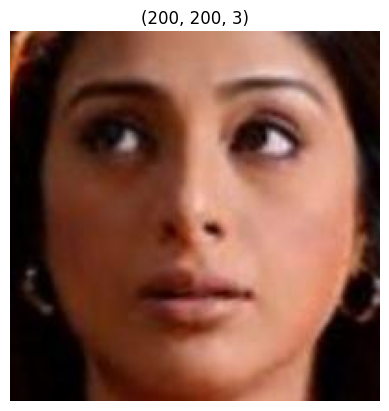

21_0_0_20170103234805676.jpg.chip.jpg: (200, 200, 3)



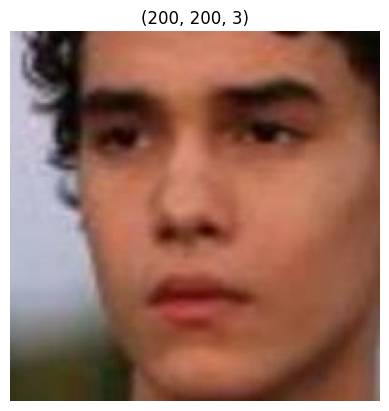

image: (4000, 224, 224, 3) age (4000,)
(3200, 224, 224, 3) ,, (800, 224, 224, 3)
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - loss: 327.6269 - mae: 13.8327 - val_loss: 210.0691 - val_mae: 10.8659
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 177.7335 - mae: 10.2539 - val_loss: 171.2296 - val_mae: 9.8243
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 154.2200 - mae: 9.5092 - val_loss: 155.0316 - val_mae: 9.4974
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 137.1609 - mae: 8.8592 - val_loss: 147.8265 - val_mae: 9.1776
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 129.4557 - mae: 8.5907 - val_loss: 143.1088 - val_mae: 9.0154
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 121.4293 - mae: 8.3569 - val_loss: 153.2444 - val_mae: 9.7426
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 115.2385 - mae: 8.1210 - val_loss: 138.3981 - val_mae: 8.6929
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step -

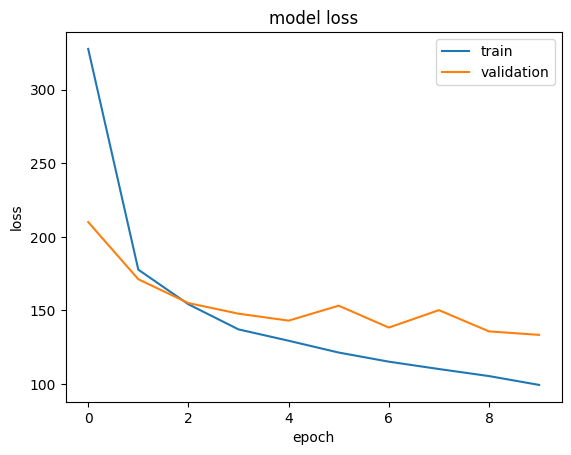

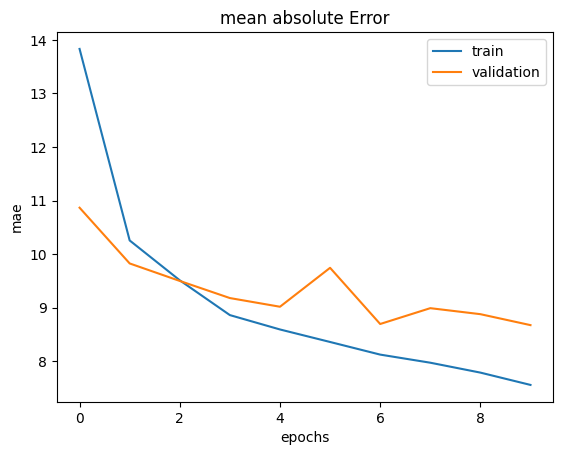

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step
real= 2 predicted age =  7.375277
real= 65 predicted age =  49.82283
real= 39 predicted age =  37.73121
real= 50 predicted age =  37.39482
real= 62 predicted age =  73.53041
real= 32 predicted age =  29.003605
real= 1 predicted age =  5.7397017
real= 3 predicted age =  4.6926727
real= 62 predicted age =  50.899017
real= 26 predicted age =  28.630281


In [3]:
#imports
import tensorflow as tf
from tensorflow import keras
from keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping ,ModelCheckpoint
import matplotlib.pyplot as plt
from tensorflow.keras.utils import img_to_array , load_img


#load dataset
#0=> man   1=>woman shape 200,200,3
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

folder = '/content/datas/UTKFace'
folder = '/content/datas/crop_part1'
folder = '/content/utkface_aligned_cropped/crop_part1'

for filename in os.listdir(folder)[:2]:
    path = os.path.join(folder, filename)

    img = Image.open(path)
    arr = np.array(img)

    print(f"{filename}: {arr.shape}\n")

    plt.imshow(arr)
    plt.title(arr.shape)
    plt.axis('off')
    plt.show()


# x=image pixel
#y =age
#image number = 23708
X , Y = [] ,[]
folder = '/content/datas/UTKFace'
for filename in os.listdir(folder)[:4000]:
 # try:
    age = int(filename.split('_')[0])
    img = load_img(
        os.path.join(folder , filename),
        target_size = (224 , 224) )
    img = img_to_array(img)/255.0
    X.append(img)
    Y.append(age)

 # except:
   # pass

X = np.array(X)
Y = np.array(Y)
print('image:',X.shape , 'age' , Y.shape)




#divide trining and testing sets 20,80
from sklearn.model_selection import train_test_split
x_train,x_test , y_train , y_test = train_test_split(
    X , Y ,test_size=0.2 , random_state=40
)
print(x_train.shape , ',,',x_test.shape)

#configure model
from keras.models import Sequential
from keras.applications import MobileNet
from keras.layers import GlobalAveragePooling2D , Dense
from tensorflow.keras.models import Model
base_model = MobileNet(
    weights = 'imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False
model=Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128,activation='relu'),
    Dense(1) #age preediction
])


# define loss function optimizer

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)




#finetune pretrained model
#train the model
history = model.fit(
    x_train , y_train ,
    validation_data = (x_test , y_test),
    epochs = 10 ,
    batch_size = 32
)

#evaluate the model
loss , mae = model.evaluate(x_test , y_test)
print("loss , mae  : " , loss , '_',mae)

#visualize training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','validation'])
plt.show()
plt.plot(history.history['mae'])
plt.plot(history.history['val_mae'])
plt.title('mean absolute Error')
plt.xlabel('epochs')
plt.ylabel('mae')
plt.legend(['train','validation'])
plt.show()



#make prediction on test images
prediction = model.predict(x_test)
for i in range(10):
  print('real=',y_test[i]   ,'predicted age = ',prediction[i][0])







